# Single Particle Transport

In [1]:
# This notebook corresponds to the multi-particle transport (same target) algorithm from the
# paper listed in this repository: https://github.com/quasarsrus/Multi-Particle-Transport-Viscous-Streaming-RL/tree/main .

# The first section trains the RL agent to transport a single agent to the target. If one desires to skip this stage,
# simply refrain from executing cells marked with "X" at the top.

In [2]:
# To download viscous streaming, use the command "Pkg.add(url = "https://github.com/jdeldre/ViscousStreaming.jl").
# Viscous Streaming is an 'older' package. There might be sub-dependencies that have version clashes.
# Preferably, run this on Julia v1.4.2.

using Pkg
using Plots
using ViscousStreaming
using NBInclude
using HDF5
using JLD2
using Distributions

In [3]:
# A lookup table for the particle velocity fields for all 15 actions (the last one is the null action). 
# To generate a customised version of this, tinker with "".

strdVuxy = load("strdVuxy_square.jld2")["data"];
strdVvxy = load("strdVvxy_square.jld2")["data"];

In [4]:
# Some default configurations as used in https://github.com/jdeldre/ViscousStreaming.jl.

 Re = 40
 ϵ = 0.1
 Ω = 1.0 # frequency (keep this equal to 1)
 Tp = 2π/Ω # one period of oscillation
 p = StreamingParams(ϵ,Re)

 τ = 0.1 # Stokes number, should be small
 β = 0.95 # Density parameter. Less than 1 means heavier than fluid.
 p_inert = InertialParameters(tau=τ,beta=β,epsilon=ϵ,Re=Re)
 Ω = 1.0
 Tp = 2π/Ω
 Tmax = 50*Tp

 Δx = 0.02
 xlim = (-3.25,3.25)
 ylim = (-3.25,3.25)
 n = 75
 body = Circle(0.2,n)

Circular body with 72 points and radius 0.2
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


In [5]:
bl = BodyList()
bL1 = deepcopy(body)
bL2 = deepcopy(body)
bR1 = deepcopy(body)
bR2 = deepcopy(body)

# left 1 cylinder
cent = (-2.0,2.0)
α = 0.0
TL = RigidTransform(cent,α)
TL(bL1) # transform the body to the current configuration

# left 2 cylinder
cent = (-2.0,-2.0)
α = 0.0
TL = RigidTransform(cent,α)
TL(bL2) # transform the body to the current configuration

# right 1 cylinder
cent = (2.0,2.0)
α = 0.0
TR = RigidTransform(cent,α)
TR(bR1) # transform the body to the current configuration

# right 2 cylinder
cent = (2.0,-2.0)
α = 0.0
TR = RigidTransform(cent,α)
TR(bR2) # transform the body to the current configuration

push!(bl,bL1);
push!(bl,bL2);
push!(bl,bR1);
push!(bl,bR2);

In [6]:
# Generating a discrete action space of 15 actions (the action of 'doing nothing' is handled separately).

 ampvec = [ComplexF64[0.0,0.0] for i in 1:length(bl)];
 ampvec[1] = [1,0];  a2 = deepcopy(ampvec);
 ampvec[2] = [1,0];  a3 = deepcopy(ampvec); 
 ampvec[3] = [1,0];  a4 = deepcopy(ampvec); 
 ampvec[4] = [1,0];  a5 = deepcopy(ampvec);
 ampvec[1] = [0,0];  a6 = deepcopy(ampvec);
 ampvec[2] = [0,0];  a7 = deepcopy(ampvec);
 ampvec[3] = [0,0];  a8 = deepcopy(ampvec);
 ampvec[2] = [1,0];  a9 = deepcopy(ampvec);
 ampvec[1] = [1,0];  a10 = deepcopy(ampvec);
 ampvec[2] = [0,0];  a11 = deepcopy(ampvec);
 ampvec[3] = [1,0];  a12 = deepcopy(ampvec);
 ampvec[4] = [0,0];  a13 = deepcopy(ampvec);
 ampvec[1] = [0,0];  a14 = deepcopy(ampvec);
 ampvec[2] = [1,0];  a15 = deepcopy(ampvec);
 ampvec[3] = [0,0];  a16 = deepcopy(ampvec);

 actionspace = [a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12, a13, a14, a15, a16];

In [7]:
function mean_motion(dR,R,p,t,v̄Luxy,v̄Lvxy)
    dR[1] = v̄Luxy(R[1],R[2])
    dR[2] = v̄Lvxy(R[1],R[2])
   return dR 
end

# Particle is initialised between [-1.8, 1.8] x [-1.8, 1.8]

function reset1()
    px = rand(Uniform(-1.8,1.8))
    py = rand(Uniform(-1.8,1.8))
    return (px,py)
end

# This function is responsible for cylinder actuation and particle motion. 
# The target here is the origin. The commented section is shown as an example
# for the case when a different target region is desired (the region being 
# around (1,0))

function motion(curstate, ampvel_ind)
    newposx = 0
    newposy = 0
    done = false
    
    if ampvel_ind == 16
        newposx, newposy = curstate
    else
        v̄Lfcn(dR,R,p,t) = mean_motion(dR,R,p,t,strdVuxy[ampvel_ind],strdVvxy[ampvel_ind])
        solL = compute_trajectory(v̄Lfcn,curstate,Tmax,10Tp,bl=bl,ϵ=p.ϵ);
        newposx = last(solL[1,:])
        newposy = last(solL[2,:])
    end
    
    if newposx < -2.8  || newposx > 2.8  || newposy < -2.8  || newposy > 2.8 
        reward = -50
        newposx,newposy = curstate
    elseif newposx < 0.1  && newposx > -0.1  && newposy < 0.1  && newposy > -0.1
        reward = 2 - (abs(newposx) + abs(newposy)) 
        if newposx < 0.02  && newposx > -0.02  && newposy < 0.02  && newposy > -0.02 
            reward = 1000
            done = true
        end
    else
        reward = -1
    end
    """
    if newposx < -1.8  || newposx > 1.8  || newposy < -1.8  || newposy > 1.8 
        reward = -50
        newposx,newposy = curstate
    elseif newposx < 1.1  && newposx > 0.9  && newposy < 0.1  && newposy > -0.1
        reward = 2 - (abs(1-newposx) + abs(newposy-0)) 
        if newposx < 1.02  && newposx > 0.98  && newposy < 0.02  && newposy > -0.02 
            reward = 1000
            done = true
        end
    else
        reward = -1
    end
    """
    
    return (newposx,newposy), reward, done
end


motion (generic function with 1 method)

In [ ]:
# "X"

# Main function for learning a RL controller to transport a single particle to the target

function main()
    scores = []
    episode_history = []
    episodes = 1000

    for i in 1:episodes
        done = false
        score = 0
        obs = reset1()
        j = 0
        while !done
            action = action_choice(obs) 
            obs_new, reward, done = motion(obs, action)
            score += reward 
            remember(obs, action, reward, obs_new, done)
            obs = obs_new
            learn()
            j += 1
            if j == 200
              break
            end
        end
                
        append!(episode_history,agentdata.epsilon)
        append!(scores,score)
        
        avgscore = mean(scores[max(1, i-100):(i)])
        #if i%50 == 0
            println("score -> $score, episode -> $i, Average Score -> $avgscore")
        #end
    end
        #if i%10 == 0 and i>0:
        #    savemodel()
end      


In [8]:
# Calls another notebook that contains the implementation of DQN 

@nbinclude("DQN_Partm.ipynb")

Dict{Any,Any} with 8 entries:
  "W2" => [0.103835 0.195498 … -0.047897 0.0866108; 0.0418779 0.0106832 … -0.19…
  "W3" => [-0.00554889 -0.0744423 … -0.168794 0.207698; 0.100022 -0.175054 … -0…
  "W4" => [-0.168011 -0.0168662 … 0.162177 0.0396894; -0.0317866 0.151234 … -0.…
  "b3" => [0.0; 0.0; … ; 0.0; 0.0]
  "b4" => [0.0; 0.0; … ; 0.0; 0.0]
  "W1" => [0.964711 -0.180331; 1.61136 0.634442; … ; -1.13516 -0.70478; -1.5953…
  "b2" => [0.0; 0.0; … ; 0.0; 0.0]
  "b1" => [0.0; 0.0; … ; 0.0; 0.0]

In [9]:
# Uncomment this if you want to skip training and use a pre-trained model

#nn_param.param_learn = loadmodel("Weights_Partm(Centre)_Diff_bounds")

Dict{Any,Any} with 8 entries:
  "W2" => [-0.138227 -0.186301 … 0.0272445 -0.140838; 0.300678 -0.57134 … 0.556…
  "W3" => [0.109141 1.20805 … -0.573126 0.151999; -0.0129909 0.042542 … 0.42963…
  "W4" => [0.267213 0.239549 … -0.420732 -0.642193; -0.791307 0.209453 … -0.577…
  "b3" => [-0.527819; 0.494328; … ; -0.172566; -0.00230737]
  "b4" => [0.130156; 0.0583249; … ; 0.542886; 0.0662388]
  "W1" => [-0.357431 1.59339; -0.791584 -0.237095; … ; -1.68231 1.44457; 0.3139…
  "b2" => [-0.0214586; -0.111473; … ; 0.698619; 0.713717]
  "b1" => [-2.30053; 1.61034; … ; 0.440515; 1.04874]

In [ ]:
# "X"

main()

In [ ]:
#savemodel("Weights_Partm(Centre)_Diff_bounds")

# Policy Test

In [10]:
@time solver2 = FrequencyStreaming(Re,ϵ,Δx,xlim,ylim,bl);

 38.899615 seconds (1.23 G allocations: 61.922 GiB, 9.33% gc time)


In [15]:
# Policy rollout function to help check whether the controller is performing as desired

function motion_exploit(curstate, ampvel_ind)
    if ampvel_ind == 16
        newposx, newposy = curstate
        return [newposx, newposy]
    else
        v̄Lfcn(dR,R,p,t) = mean_motion(dR,R,p,t,strdVuxy[ampvel_ind],strdVvxy[ampvel_ind])
        solL = compute_trajectory(v̄Lfcn,curstate,Tmax,10Tp,bl=bl,ϵ=p.ϵ);
    end
    return [solL[1,:],solL[2,:]]
end

function policyrollout(obs)
    pos7 = []
    pos8 = []
    done = false
    agentdata.epsilon = 1
    push!(pos7, obs[1])
    push!(pos8, obs[2])
    #action_chosen_ind = []
    #push!(action_chosen_ind,16)
    for i = 1:50 
        actions,_ = forward_propagation([obs[1] obs[2]], nn_param.param_learn, nn_param.activation_type)
        action = argmax(actions)[2]
        obs_new = motion_exploit(obs, action)
        for j = 1:length(obs_new[1])
            push!(pos7, obs_new[1][j])
            push!(pos8, obs_new[2][j])
            #push!(action_chosen_ind,action)
        end
        #for j = 1:length(obs_new[1])
        #    push!(action_chosen_ind,action)
        #end
        obs = (last(obs_new[1]),last(obs_new[2]))
    end
    return pos7, pos8#, action_chosen_ind
end

policyrollout (generic function with 1 method)

In [18]:
pos1, pos2 = policyrollout(reset1());
pos3, pos4 = policyrollout(reset1());
pos5, pos6 = policyrollout(reset1());
pos7, pos8 = policyrollout(reset1());

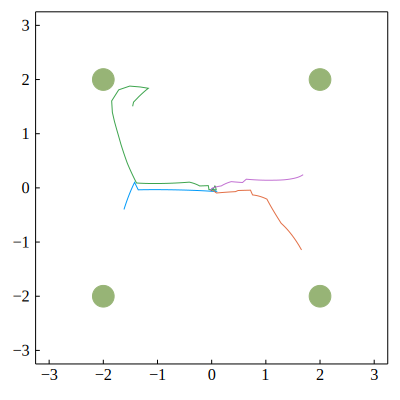

In [19]:
# Plot to visualise the result

soln = solver2([ComplexF64[0.0,0.0] for i in 1:length(bl)], bl);
xg, yg = coordinates(soln.s1.W,solver2.grid)
plot(pos1, pos2, ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim,
    tickfont = font(10, "Times"),
    size = (400, 400),
    markerstrokewidth = 0)
plot!(pos3, pos4, ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
plot!(pos5, pos6, ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
plot_1 = plot!(pos7, pos8, ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
plot!(xg,yg,vorticity(0,soln.s1) , levels=range(-2,2,length=30),clim=(-2,2),xlim=xlim,ylim=ylim)
plot!(bl)
#savefig(plot_1, "trajectories.png")

# Multi-Particle Transport (Same Target)

In [ ]:
# Here, we demonstrate the execution of Alg. 1, where multiple inertial particles
# of the same configuration are collected together and transported to the
# same target

In [22]:
# Helper functions

function trap_nparticles(obs,amp_ind,max_t)
    
    v̄Lfcn(dR,R,p,t) = mean_motion(dR,R,p,t,strdVuxy[amp_ind],strdVvxy[amp_ind])   
    temp_trap = [] 
    
    for i = 1:length(obs)
        push!(temp_trap,compute_trajectory(v̄Lfcn,obs[i],max_t*Tp,10Tp,bl=bl,ϵ=p.ϵ);)
    end    
    
    return temp_trap
    
end

function nulllist_dict(n_states)
    
    temp_dict = Dict()  
    for i = 1:2:2*n_states
        temp_dict[string("pos",i)] = []
        temp_dict[string("pos",i+1)] = []
    end
    
    return temp_dict
end
    
function append_states(dict,pos)
    
    j = 1
    for i = 1:length(pos)   
        push!(dict[string("pos",j)],pos[i][1])
        push!(dict[string("pos",j+1)],pos[i][2])
        j += 2
    end
    
    return dict
end
    
function closeness_measure(obs)
    
    for i = 1:length(obs)-1
        for j = i+1:length(obs)
            if (sqrt((obs[i][1]-obs[j][1])^2 + (obs[i][2] - obs[j][2])^2) > 0.1)     
                return false
            end
        end
    end
    return true
end

function greedy_action(obs, single)
    
    if single
        actions,_ = forward_propagation([obs[1][1] obs[1][2]], nn_param.param_learn, nn_param.activation_type)
    end
    temp = []
    
    for i = 1:length(obs)
        if !single
            actions,_ = forward_propagation([obs[i][1] obs[i][2]], nn_param.param_learn, nn_param.activation_type) 
        end
        temp_inst = greedy_motion(obs[i], argmax(actions)[2])
        push!(temp,(temp_inst))
    end
    
    return temp,argmax(actions)[2]
    
end

function trajectory_coord(dict, trapped_parts)
    
    for i = 1:length(trapped_parts[1][1,:])
        obs = [(trapped_parts[j][1,i],trapped_parts[j][2,i]) for j = 1:length(trapped_parts)]
        dict = append_states(dict, obs)
    end
    
    return dict 
end

function extract_last_pos(dict, num_ele)
    
    temp = []
    for i = 1:2:2*num_ele
        push!(temp,(last(dict[string("pos",i)]), last(dict[string("pos",i+1)])))
    end

    return temp
end

function greedy_motion(curstate, ampvel_ind)
    newposx = 0
    newposy = 0
    
    if ampvel_ind == 16
        newposx, newposy = curstate
    else
        
        v̄Lfcn(dR,R,p,t) = mean_motion(dR,R,p,t,strdVuxy[ampvel_ind],strdVvxy[ampvel_ind])
        solL = compute_trajectory(v̄Lfcn,curstate,Tmax,10Tp,bl=bl,ϵ=p.ϵ);
        newposx = last(solL[1,:])
        newposy = last(solL[2,:])

    end
    return (newposx, newposy)
end

greedy_motion (generic function with 1 method)

In [20]:
function policyrollout_diff_test_varargs(obs...)
    agentdata.epsilon = 1
        
    positions = nulllist_dict(length(obs))

    positions = append_states(positions, obs)
    
    action_chosen_ind = []
    push!(action_chosen_ind,1)

    il = 0
    while true
           
        trap_trajectories = trap_nparticles(obs,1,5000)
        
        for i = 1:size(trap_trajectories[1])[2]
            push!(action_chosen_ind,1)
        end
            
        positions = trajectory_coord(positions, trap_trajectories)
        il+=1
        println(il)
        
        obs = [(last(positions[string("pos",i)]), last(positions[string("pos",i+1)])) for i = 1:2:2*length(obs)]
        
        if (closeness_measure(extract_last_pos(positions, length(obs))))
            break
        end
        
        if (il>10)
            break
        end        
    end
            
    for i = 1:50
        obs,act_indx = greedy_action(obs, true)
        push!(action_chosen_ind,act_indx)
        positions = append_states(positions, obs)
        
    end
    return positions,action_chosen_ind
end

policyrollout_diff_test_varargs (generic function with 1 method)

In [23]:
num_elements = 5
pos_dict,lm = policyrollout_diff_test_varargs((-1.0,-1.0),(0.8,-0.5),(0.1,0.1), (-1.0, 1.0), (-1.5, 0.0));

1
2
3
4


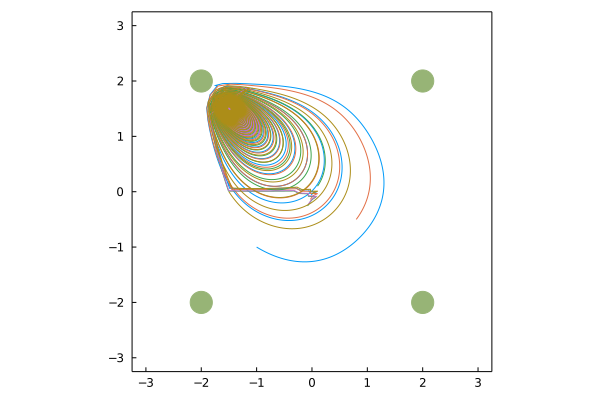

In [24]:
# Plot the final result

soln = solver2([ComplexF64[0.0,0.0] for i in 1:length(bl)], bl);
xg, yg = coordinates(soln.s1.W,solver2.grid)
plot(pos_dict["pos1"], pos_dict["pos2"], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
for i = 1:2:(2*num_elements)-2
    plot!(pos_dict[string("pos",i+2)], pos_dict[string("pos",i+3)], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
end
plot!(xg,yg,vorticity(0,soln.s1) , levels=range(-2,2,length=30),clim=(-2,2),xlim=xlim,ylim=ylim)
plot!(bl)

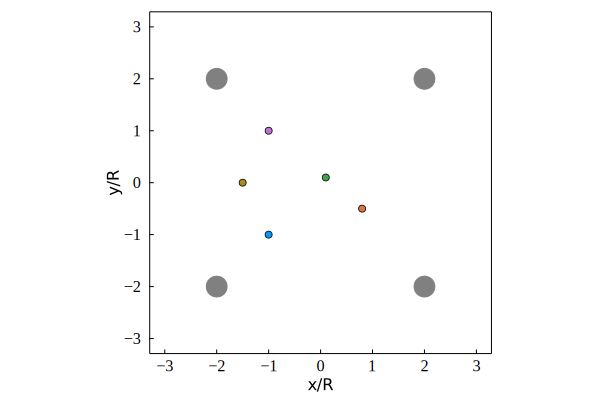

In [26]:
# Initial particle locations

soln_0 = solver2([ComplexF64[0.0,0.0] for i in 1:length(bl)],bl);

scatter([pos_dict["pos1"][1]], [pos_dict["pos2"][1]], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim,
    tickfont = font(10, "Times"))

for i = 1:2:(2*num_elements)-2
    scatter!([pos_dict[string("pos",i+2)][1]], [pos_dict[string("pos",i+3)][1]], ratio=1,legend=false,linewidth=1,
        xlim=xlim,ylim=ylim, tickfont = font(10, "Times"))
end

plot!(lagrangian_mean_streamfunction(soln_0), soln_0.g, levels=15, color=:black, linewidth=0.5)
plot_3 = plot!(bl, fillcolor=:gray, linecolor=:gray)
#savefig(plot_3, "multi_particle_transport_1.png")

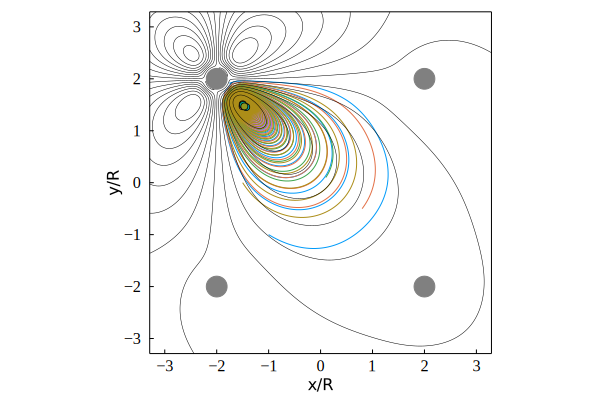

In [28]:
# Particles after some time period.

soln = solver2(actionspace[1], bl);
xg, yg = coordinates(soln.s1.W,solver2.grid)
plot(pos_dict["pos1"][1:4005], pos_dict["pos2"][1:4005], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
for i = 1:2:(2*num_elements)-2
    plot!(pos_dict[string("pos",i+2)][1:4005], pos_dict[string("pos",i+3)][1:4005], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
end

scatter!([pos_dict["pos1"][4005]], [pos_dict["pos2"][4005]], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim,
    tickfont = font(10, "Times"))

for i = 1:2:(2*num_elements)-2
    scatter!([pos_dict[string("pos",i+2)][4005]], [pos_dict[string("pos",i+3)][4005]], ratio=1,legend=false,linewidth=1,
        xlim=xlim,ylim=ylim, tickfont = font(10, "Times"))
end

plot!(lagrangian_mean_streamfunction(soln),soln.g,levels=15,color=:black,linewidth=0.5)
plot_4 = plot!(bl,fillcolor=:gray,linecolor=:gray)
#savefig(plot_4, "multi_particle_transport_2.png")

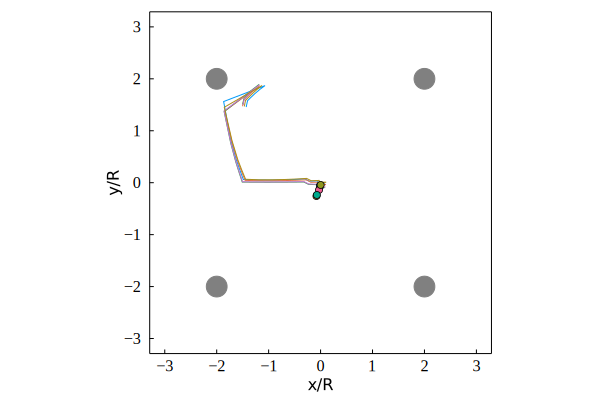

In [29]:
# Once it was realised that the particles were close, the learnt DQN controller was used
# to collectively bring them to the origin (could be a different location depending on the controller).

soln = solver2([ComplexF64[0.0,0.0] for i in 1:length(bl)], bl);
xg, yg = coordinates(soln.s1.W,solver2.grid)
plot(pos_dict["pos1"][4005:end], pos_dict["pos2"][4005:end], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
for i = 1:2:(2*num_elements)-2
    plot!(pos_dict[string("pos",i+2)][4005:end], pos_dict[string("pos",i+3)][4005:end], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
end

scatter!([pos_dict["pos1"][end]], [pos_dict["pos2"][end]], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim,
    tickfont = font(10, "Times"))

for i = 1:2:(2*num_elements)-2
    scatter!([pos_dict[string("pos",i+2)][end]], [pos_dict[string("pos",i+3)][end]], ratio=1,legend=false,linewidth=1,
        xlim=xlim,ylim=ylim, tickfont = font(10, "Times"))
end

plot!(lagrangian_mean_streamfunction(soln),soln.g,levels=15,color=:black,linewidth=0.5)
plot_5 = plot!(bl,fillcolor=:gray,linecolor=:gray)
#savefig(plot_5, "multi_particle_transport_3.png")

 94.419063 seconds (932.21 M allocations: 23.572 GiB, 2.54% gc time)


┌ Info: Saved animation to 
└   fn = "/home/apujari1/anaconda3/tmp.gif"


Plots.AnimatedGif("/home/apujari1/anaconda3/tmp.gif")
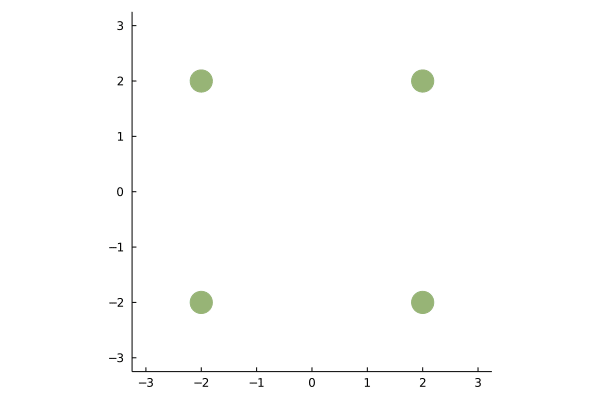

In [30]:
# An animation of the entire process

soln = solver2([ComplexF64[0.0,0.0] for i in 1:length(bl)], bl);
xg, yg = coordinates(soln.s1.W,solver2.grid)
@time @gif for k = 1:length(pos_dict["pos1"])
    plot(pos_dict["pos1"][1:k], pos_dict["pos2"][1:k], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
    for i = 1:2:(2*num_elements)-2
         plot!(pos_dict[string("pos",i+2)][1:k], pos_dict[string("pos",i+3)][1:k], ratio=1,legend=false,linewidth=1,xlim=xlim,ylim=ylim)
    end
    plot!(bl)
    #if lm[k] != 16
    #    scatter!(cyl_type_x[lm[k]],cyl_type_y[lm[k]] , mc=:blue, ms=14)
    #end  
end